# DAM Project Notebook  
## Expanding the Feature Space for Truthfulness Classification on the LIAR Dataset

This notebook presents an **application-style data mining project** on the **LIAR** fact-checking dataset.  
The main goal is to predict the truthfulness of a political statement and to show, through controlled experiments, how performance changes as we expand the feature space beyond plain text.

## Project objective

The core research question is:

> **How much can truthfulness classification improve when we move from a text-only baseline to a richer feature space that includes metadata, speaker-history signals, and similar-claim retrieval features?**

To answer this, the notebook compares a simple baseline with progressively stronger models and reports both quantitative results and qualitative error analysis.

## Pipeline overview

The project is organized as a step-by-step experimental pipeline:

- **Baseline:** TF-IDF + Multinomial Naive Bayes on the cleaned statement text
- **Improvement 1:** metadata feature engineering
- **Improvement 2:** speaker-history / credibility features
- **Improvement 3:** similar-claim retrieval features using MinHash + LSH
- **Final comparison:** improved linear model vs improved XGBoost model

## Why this project fits the course

This project uses:
- a **real dataset** (`LIAR`)
- methods that are clearly related to course topics in **classification, feature engineering, similarity search / retrieval, and evaluation**
- a structured experimental comparison with **baselines, ablations, plots, and error analysis**

## Important note on scope

The original idea of using **retweet / propagation graphs** is **not compatible** with the LIAR TSV files alone, because LIAR does not provide a social diffusion network.  
Therefore, this notebook focuses on a **reproducible metadata- and retrieval-based extension** of the LIAR task instead of claiming to use unavailable graph data.

## Binary formulation used here

Although LIAR is originally a **six-class** dataset, the main experiments in this notebook use a **binary formulation** to stay aligned with the current project direction:

- **true class**: `true`, `mostly-true`, `half-true`, `barely-true`
- **false class**: `false`, `pants-fire`

An optional six-class sanity-check section is included early in the notebook, but the main comparison table focuses on the binary setup.

## How to run this notebook

Run the notebook **from top to bottom** in order.  
It expects the following files to exist relative to the notebook:

- `data/train.tsv`
- `data/valid.tsv`
- `data/test.tsv`

Outputs such as comparison tables and error-analysis files are written to:

- `data/liar_project_outputs_no_graph/`

## What to look for in the final sections

The most important deliverables inside this notebook are:

- the **consolidated comparison table**
- the **ablation study**
- the **plots comparing models**
- the **error analysis examples**
- the **threshold-tuning analysis**

Together, these sections support the final discussion about what feature groups matter most and where the models still fail.

In [1]:

# Step 0: Imports, configuration, and reproducibility

import os
import re
import math
import random
import hashlib
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import ParameterGrid, ParameterSampler

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)

output_dir = "outputs/liar_project_outputs"
plot_dir = os.path.join(output_dir, "figures")
table_dir = os.path.join(output_dir, "tables")

os.makedirs(plot_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


# 1. Data Loading

In [2]:

# Step 1: Load the LIAR dataset and construct binary labels

LIAR_COLUMNS = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

TRUE_GROUP = {"true", "mostly-true", "half-true", "barely-true"}
FALSE_GROUP = {"false", "pants-fire"}


def read_liar_split(path):
    return pd.read_csv(path, sep="	", header=None, names=LIAR_COLUMNS)


def to_binary_label(label):
    if pd.isna(label):
        return None
    if label in TRUE_GROUP:
        return 1
    if label in FALSE_GROUP:
        return 0
    return None


train_path = "data/train.tsv"
valid_path = "data/valid.tsv"
test_path = "data/test.tsv"

train_df = read_liar_split(train_path)
valid_df = read_liar_split(valid_path)
test_df = read_liar_split(test_path)

for df in [train_df, valid_df, test_df]:
    df["y"] = df["label"].map(to_binary_label)

train_df = train_df.dropna(subset=["y"]).copy()
valid_df = valid_df.dropna(subset=["y"]).copy()
test_df = test_df.dropna(subset=["y"]).copy()

for df in [train_df, valid_df, test_df]:
    df["y"] = df["y"].astype(int)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test  shape:", test_df.shape)
display(train_df.head())


Train shape: (10240, 15)
Valid shape: (1284, 15)
Test  shape: (1267, 15)


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,y
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,0
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1


### Notes on dataset construction

The LIAR splits are loaded from TSV files with a fixed column schema.  
At this stage, the notebook constructs the working target variable and standardizes the text field used by downstream models.

Two label settings appear in the notebook:

- an **optional six-class view** for sanity checking class balance and feasibility
- the **main binary label mapping** used for the core experiments

This separation is useful because the six-class version preserves the original label granularity, while the binary version makes it easier to study whether richer feature engineering improves discrimination between broadly **true-like** and **false-like** claims.

In [3]:

# Step 2: Text cleaning utilities

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, valid_df, test_df]:
    df["statement_clean"] = df["statement"].apply(clean_text)

display(train_df[["statement", "statement_clean"]].head())


,statement,statement_clean
0,Says the Annies List political group supports ...,says the annies list political group supports ...
1,When did the decline of coal start? It started...,when did the decline of coal start it started ...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees with john mccain by vot...
3,Health care reform legislation is likely to ma...,health care reform legislation is likely to ma...
4,The economic turnaround started at the end of ...,the economic turnaround started at the end of ...


## Optional sanity check: six-class baseline

In [4]:

# Step 3: Six-class label mapping and baseline

LABEL_ORDER = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
LABEL_TO_INT = {label: i for i, label in enumerate(LABEL_ORDER)}


def to_six_class_label(label):
    if pd.isna(label):
        return None
    return LABEL_TO_INT.get(label, None)

train_df6 = read_liar_split(train_path)
valid_df6 = read_liar_split(valid_path)
test_df6 = read_liar_split(test_path)

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["label"].apply(to_six_class_label)
    df["statement_clean"] = df["statement"].apply(clean_text)

train_df6 = train_df6.dropna(subset=["y"]).copy()
valid_df6 = valid_df6.dropna(subset=["y"]).copy()
test_df6 = test_df6.dropna(subset=["y"]).copy()

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["y"].astype(int)

y_train6 = train_df6["y"].values
y_test6 = test_df6["y"].values

vectorizer6 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True
)
X_train6 = vectorizer6.fit_transform(train_df6["statement_clean"])
X_test6 = vectorizer6.transform(test_df6["statement_clean"])

nb6 = MultinomialNB(alpha=0.5)
nb6.fit(X_train6, y_train6)
test_pred_nb6 = nb6.predict(X_test6)

print("Six-class NB — Test Report:")
print(classification_report(y_test6, test_pred_nb6, target_names=LABEL_ORDER, digits=4))


Six-class NB — Test Report:
              precision    recall  f1-score   support

  pants-fire     0.0000    0.0000    0.0000        92
       false     0.2597    0.3213    0.2873       249
 barely-true     0.2672    0.1462    0.1890       212
   half-true     0.2169    0.3396    0.2647       265
 mostly-true     0.2397    0.3154    0.2724       241
        true     0.2613    0.1394    0.1818       208

    accuracy                         0.2415      1267
   macro avg     0.2075    0.2103    0.1992      1267
weighted avg     0.2296    0.2415    0.2251      1267



# 2. Quick Exploratory Checks


Train
-----
Rows: 10240
Class counts:
y
0    2834
1    7406
Name: count, dtype: int64

Missing values:
speaker_job_title       2898
state_info              2210
context                  102
subject                    2
speaker                    2
party_affiliation          2
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
dtype: int64

Validation
----------
Rows: 1284
Class counts:
y
0    379
1    905
Name: count, dtype: int64

Missing values:
speaker_job_title    345
state_info           279
context               12
dtype: int64

Test
----
Rows: 1267
Class counts:
y
0    341
1    926
Name: count, dtype: int64

Missing values:
speaker_job_title    325
state_info           262
context               17
dtype: int64


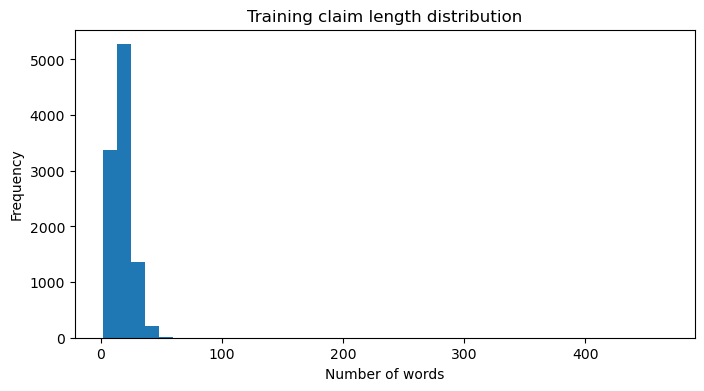

In [5]:

# Step 4: Basic exploratory analysis

def summarize_split(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows:", len(df))
    print("Class counts:")
    print(df["y"].value_counts().sort_index())
    print("\nMissing values:")
    missing = df.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

summarize_split(train_df, "Train")
summarize_split(valid_df, "Validation")
summarize_split(test_df, "Test")

for df in [train_df, valid_df, test_df]:
    df["statement_len_words_raw"] = df["statement"].fillna("").str.split().apply(len)

plt.figure(figsize=(8, 4))
plt.hist(train_df["statement_len_words_raw"], bins=40)
plt.title("Training claim length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()


# 3. Evaluation Helpers

In [6]:

# Step 5: Common evaluation helpers

y_train = train_df["y"].values
y_valid = valid_df["y"].values
y_test = test_df["y"].values


def evaluate_predictions(y_true, y_pred, y_prob=None, split_name="Split", verbose=True):
    acc = accuracy_score(y_true, y_pred)
    precision_bin, recall_bin, f1_bin, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_by_class, recall_by_class, f1_by_class, support_by_class = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], average=None, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "binary_precision": precision_bin,
        "binary_recall": recall_bin,
        "binary_f1": f1_bin,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "false_recall": recall_by_class[0],
        "true_recall": recall_by_class[1],
    }

    if y_prob is not None:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob)

    if verbose:
        print(f"{split_name} Accuracy      : {metrics['accuracy']:.4f}")
        print(f"{split_name} Binary-F1     : {metrics['binary_f1']:.4f}")
        print(f"{split_name} Macro-F1      : {metrics['macro_f1']:.4f}")
        print(f"{split_name} False Recall  : {metrics['false_recall']:.4f}")
        print(f"{split_name} True Recall   : {metrics['true_recall']:.4f}")
        if y_prob is not None:
            print(f"{split_name} AUC-ROC       : {metrics['auc_roc']:.4f}")

    return metrics


def make_results_row(model_name, valid_metrics, test_metrics):
    row = {
        "model": model_name,
        "valid_accuracy": valid_metrics["accuracy"],
        "valid_binary_f1": valid_metrics["binary_f1"],
        "valid_macro_f1": valid_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_binary_f1": test_metrics["binary_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_false_recall": test_metrics["false_recall"],
    }
    if "auc_roc" in test_metrics:
        row["test_auc_roc"] = test_metrics["auc_roc"]
    return row


# 4. Baseline: TF-IDF + Multinomial Naive Bayes

We begin with a text-only baseline built from the cleaned claim statement. Each claim is represented by unigram and bigram TF-IDF features, and a Multinomial Naive Bayes classifier is trained on that sparse representation.

## 4.1 Model Formulation

Let a document be represented by a vector $x = (x_1, x_2, \dots, x_V)$, where $x_j$ denotes the weight of term $j$ and $V$ is the vocabulary size. Under the multinomial Naive Bayes model, where $w_j$ represents the j-th word/term in the vocabulary:

$$
P(x \mid y) = \prod_{j=1}^{V} P(w_j \mid y)^{x_j}.
$$

By Bayes' rule,

$$
P(y \mid x) = \frac{P(y)\,P(x \mid y)}{P(x)}.
$$

Since $P(x)$ does not depend on the class label, the prediction rule can be written as

$$
\hat{y} = \arg\max_{y} P(y)\,P(x \mid y).
$$

Taking logarithms gives the additive decision function

$$
\hat{y} = \arg\max_{y} \left( \log P(y) + \sum_{j=1}^{V} x_j \log P(w_j \mid y) \right).
$$

This additive form is attractive for high-dimensional sparse text because each term contributes independently to the final class score.

## 4.2 Role of the Baseline

The baseline serves as the text-only reference point for the rest of the notebook. It tells us how much predictive signal can be extracted from the wording of the claim alone, before any metadata, retrieval-based, or graph-derived information is introduced.

The conditional independence assumption is clearly simplified for natural language, since words in a sentence are not truly independent. Even so, the model remains useful here because it is efficient, reproducible, and often competitive on sparse bag-of-words representations. More importantly, it provides a clear reference for evaluating how much the later feature-space expansions improve the task.

Baseline performance
Validation Accuracy      : 0.7126
Validation Binary-F1     : 0.8281
Validation Macro-F1      : 0.4758
Validation False Recall  : 0.0686
Validation True Recall   : 0.9823
Validation AUC-ROC       : 0.6504
Test Accuracy      : 0.7301
Test Binary-F1     : 0.8417
Test Macro-F1      : 0.4636
Test False Recall  : 0.0469
Test True Recall   : 0.9816
Test AUC-ROC       : 0.6591

Classification report on test:
              precision    recall  f1-score   support

           0     0.4848    0.0469    0.0856       341
           1     0.7366    0.9816    0.8417       926

    accuracy                         0.7301      1267
   macro avg     0.6107    0.5143    0.4636      1267
weighted avg     0.6689    0.7301    0.6382      1267



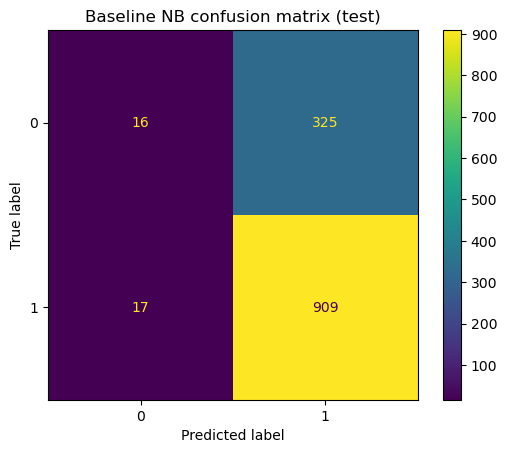

In [7]:

# Step 6: Baseline model - TF-IDF + Multinomial Naive Bayes

baseline_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True,
)

X_train_text = baseline_vectorizer.fit_transform(train_df["statement_clean"])
X_valid_text = baseline_vectorizer.transform(valid_df["statement_clean"])
X_test_text = baseline_vectorizer.transform(test_df["statement_clean"])

baseline_nb = MultinomialNB(alpha=0.5)
baseline_nb.fit(X_train_text, y_train)

valid_pred_nb = baseline_nb.predict(X_valid_text)
test_pred_nb = baseline_nb.predict(X_test_text)
prob_valid_nb = baseline_nb.predict_proba(X_valid_text)[:, 1]
prob_nb = baseline_nb.predict_proba(X_test_text)[:, 1]

print("Baseline performance")
baseline_valid_metrics = evaluate_predictions(y_valid, valid_pred_nb, prob_valid_nb, "Validation")
baseline_test_metrics = evaluate_predictions(y_test, test_pred_nb, prob_nb, "Test")

print("\nClassification report on test:")
print(classification_report(y_test, test_pred_nb, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline NB confusion matrix (test)")
plt.show()


# 5. Improvement 1: Metadata Feature Engineering

The first major feature-space expansion introduces information that is already present in LIAR, but not yet expressed in a form that a classifier can use directly and effectively.

## 5.1 Feature Construction

We use the following categorical metadata fields:
- `subject`
- `speaker`
- `speaker_job_title`
- `state_info`
- `party_affiliation`
- `context`

After cleaning missing values and grouping rare categories, these fields are encoded with one-hot encoding.

In addition, the dataset provides five speaker-history count fields:
- `barely_true_counts`
- `false_counts`
- `half_true_counts`
- `mostly_true_counts`
- `pants_on_fire_counts`

From these raw counts, we derive aggregate and ratio-based features such as:
- total historical fact-check count,
- false-oriented ratio,
- true-oriented ratio,
- extreme-false ratio,
- smoothed credibility-style scores,
- claim length in words.

## 5.2 Why These Features Matter

A claim is not determined by wording alone. The same topic may be associated with different reliability patterns across speakers, contexts, and affiliations. Similarly, the raw count history of a speaker can be transformed into prior evidence about how that speaker has been evaluated in earlier fact-checks.

The important point is that the improvement lies in the **engineered representation**, not merely in the existence of the raw columns. The notebook converts categorical, numeric, and historical information into a structured feature space that can be combined with the text representation.

## 5.3 Expected Effect

These features are intended to address a limitation of the baseline: a text-only model may miss useful context when two claims are lexically similar but come from very different speakers or political settings. Metadata and speaker-history features help the model distinguish such cases more effectively.

In [8]:

# Step 7: Metadata and speaker-history preprocessing helpers

CATEGORICAL_COLS = [
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "context",
]

HISTORY_COLS = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
]


def _clean_categorical_series(s):
    return (
        s.fillna("UNKNOWN")
         .astype(str)
         .str.strip()
         .replace("", "UNKNOWN")
    )


def fit_category_trimmer(df, categorical_cols, min_freq=3):
    keep_values = {}
    for col in categorical_cols:
        values = _clean_categorical_series(df[col])
        counts = values.value_counts()
        keep_values[col] = set(counts[counts >= min_freq].index)
        keep_values[col].add("UNKNOWN")
    return keep_values


def apply_category_trimmer(df, keep_values, categorical_cols, history_cols):
    df = df.copy()
    for col in categorical_cols:
        values = _clean_categorical_series(df[col])
        allowed = keep_values[col]
        df[col] = values.where(values.isin(allowed), "OTHER")

    for col in history_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df


def add_metadata_features(df):
    df = df.copy()
    df["statement_len_words"] = df["statement"].fillna("").str.split().apply(len)
    df["statement_len_chars"] = df["statement"].fillna("").astype(str).str.len()
    df["subject_count"] = df["subject"].fillna("").apply(
        lambda x: len([s.strip() for s in str(x).split(",") if s.strip()])
    )
    df["has_job_title"] = df["speaker_job_title"].notna().astype(int)
    df["has_state_info"] = df["state_info"].notna().astype(int)
    df["has_context"] = df["context"].notna().astype(int)
    df["is_major_party"] = df["party_affiliation"].fillna("").str.lower().isin(["democrat", "republican"]).astype(int)
    df["num_exclamation_marks"] = df["statement"].fillna("").astype(str).str.count("!")
    return df


def add_history_features(df, alpha=1.0):
    df = df.copy()

    b = df["barely_true_counts"].astype(float)
    f = df["false_counts"].astype(float)
    h = df["half_true_counts"].astype(float)
    m = df["mostly_true_counts"].astype(float)
    p = df["pants_on_fire_counts"].astype(float)

    total = b + f + h + m + p

    df["history_total"] = total
    df["false_ratio"] = (f + p) / np.where(total > 0, total, 1.0)
    df["trueish_ratio"] = (b + h + m) / np.where(total > 0, total, 1.0)
    df["extreme_false_ratio"] = p / np.where(total > 0, total, 1.0)
    df["credibility_smoothed"] = (b + h + m + alpha) / (total + 2 * alpha)
    df["history_balance"] = ((b + h + m) - (f + p)) / np.where(total > 0, total, 1.0)

    return df


METADATA_NUMERIC_COLS = [
    "statement_len_words",
    "statement_len_chars",
    "subject_count",
    "has_job_title",
    "has_state_info",
    "has_context",
    "is_major_party",
    "num_exclamation_marks",
]

SPEAKER_HISTORY_NUMERIC_COLS = HISTORY_COLS + [
    "history_total",
    "false_ratio",
    "trueish_ratio",
    "extreme_false_ratio",
    "credibility_smoothed",
    "history_balance",
]


In [9]:

# Step 8: Fit trimming rules on TRAIN only and build metadata tables

category_keep_values = fit_category_trimmer(
    train_df,
    categorical_cols=CATEGORICAL_COLS,
    min_freq=3,
)

train_meta = apply_category_trimmer(train_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)
valid_meta = apply_category_trimmer(valid_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)
test_meta = apply_category_trimmer(test_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)

train_meta = add_metadata_features(train_meta)
valid_meta = add_metadata_features(valid_meta)
test_meta = add_metadata_features(test_meta)

train_meta_history = add_history_features(train_meta)
valid_meta_history = add_history_features(valid_meta)
test_meta_history = add_history_features(test_meta)

print("Metadata numeric columns:", METADATA_NUMERIC_COLS)
print("Speaker-history numeric columns:", SPEAKER_HISTORY_NUMERIC_COLS)
display(train_meta_history.head())


Metadata numeric columns: ['statement_len_words', 'statement_len_chars', 'subject_count', 'has_job_title', 'has_state_info', 'has_context', 'is_major_party', 'num_exclamation_marks']
Speaker-history numeric columns: ['barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'history_total', 'false_ratio', 'trueish_ratio', 'extreme_false_ratio', 'credibility_smoothed', 'history_balance']


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,y,statement_clean,statement_len_words_raw,statement_len_words,statement_len_chars,subject_count,has_job_title,has_state_info,has_context,is_major_party,num_exclamation_marks,history_total,false_ratio,trueish_ratio,extreme_false_ratio,credibility_smoothed,history_balance
0,2635.json,false,Says the Annies List political group supports ...,abortion,OTHER,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0,says the annies list political group supports ...,11,11,82,1,1,1,1,1,0,1.0,1.000000,0.000000,0.000000,0.333333,-1.000000
1,10540.json,half-true,When did the decline of coal start? It started...,OTHER,OTHER,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1,when did the decline of coal start it started ...,24,24,141,1,1,1,1,1,0,2.0,0.000000,1.000000,0.000000,0.750000,1.000000
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1,hillary clinton agrees with john mccain by vot...,19,19,105,1,1,1,1,1,0,473.0,0.169133,0.830867,0.019027,0.829474,0.661734
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,UNKNOWN,UNKNOWN,none,7.0,19.0,3.0,5.0,44.0,a news release,0,health care reform legislation is likely to ma...,12,12,78,1,1,1,1,0,0,78.0,0.807692,0.192308,0.564103,0.200000,-0.615385
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,UNKNOWN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1,the economic turnaround started at the end of ...,10,10,54,2,1,1,1,1,0,65.0,0.169231,0.830769,0.030769,0.820896,0.661538


In [10]:

# Step 9: Metadata-only linear model

preprocessor_metadata = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num_metadata",
            StandardScaler(with_mean=False),
            METADATA_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

metadata_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_metadata),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

metadata_linear_pipeline.fit(train_meta, y_train)

valid_pred_metadata = metadata_linear_pipeline.predict(valid_meta)
test_pred_metadata = metadata_linear_pipeline.predict(test_meta)
prob_valid_metadata = metadata_linear_pipeline.predict_proba(valid_meta)[:, 1]
prob_metadata = metadata_linear_pipeline.predict_proba(test_meta)[:, 1]

print("Metadata-only linear model performance")
metadata_valid_metrics = evaluate_predictions(y_valid, valid_pred_metadata, prob_valid_metadata, "Validation")
metadata_test_metrics = evaluate_predictions(y_test, test_pred_metadata, prob_metadata, "Test")


Metadata-only linear model performance
Validation Accuracy      : 0.6783
Validation Binary-F1     : 0.7946
Validation Macro-F1      : 0.5266
Validation False Recall  : 0.1900
Validation True Recall   : 0.8829
Validation AUC-ROC       : 0.5887
Test Accuracy      : 0.6898
Test Binary-F1     : 0.8057
Test Macro-F1      : 0.5183
Test False Recall  : 0.1730
Test True Recall   : 0.8801
Test AUC-ROC       : 0.5737


# 6. Improvement 2: Speaker-History / Credibility Features

In [11]:

# Step 10: Metadata + speaker-history linear model

NUMERIC_METADATA_HISTORY_COLS = METADATA_NUMERIC_COLS + SPEAKER_HISTORY_NUMERIC_COLS

preprocessor_history = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num_metadata_history",
            StandardScaler(with_mean=False),
            NUMERIC_METADATA_HISTORY_COLS,
        ),
    ],
    remainder="drop",
)

history_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_history),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

history_linear_pipeline.fit(train_meta_history, y_train)

valid_pred_history = history_linear_pipeline.predict(valid_meta_history)
test_pred_history = history_linear_pipeline.predict(test_meta_history)
prob_valid_history = history_linear_pipeline.predict_proba(valid_meta_history)[:, 1]
prob_history = history_linear_pipeline.predict_proba(test_meta_history)[:, 1]

print("Metadata + speaker-history linear model performance")
history_valid_metrics = evaluate_predictions(y_valid, valid_pred_history, prob_valid_history, "Validation")
history_test_metrics = evaluate_predictions(y_test, test_pred_history, prob_history, "Test")


Metadata + speaker-history linear model performance
Validation Accuracy      : 0.7788
Validation Binary-F1     : 0.8463
Validation Macro-F1      : 0.7259
Validation False Recall  : 0.5752
Validation True Recall   : 0.8641
Validation AUC-ROC       : 0.8254
Test Accuracy      : 0.7782
Test Binary-F1     : 0.8511
Test Macro-F1      : 0.7084
Test False Recall  : 0.5367
Test True Recall   : 0.8672
Test AUC-ROC       : 0.8010


# 7. Improvement 3: Similar-Claim Retrieval Features Using MinHash + LSH

This section adds retrieval-based features so that each claim can benefit from information about similar claims in the training set.

## 7.1 Motivation

Many claims in political fact-checking data are repeated, paraphrased, or slightly reworded versions of earlier talking points. A purely supervised text classifier treats each example independently, even though a new claim may be closely related to previously seen statements.

To capture this local neighborhood structure, we retrieve similar claims and summarize their relationship to the current claim as numerical features.

## 7.2 Jaccard Similarity

Each cleaned claim is represented as a set of word shingles. Given two claims represented by sets $A$ and $B$, their Jaccard similarity is

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}.
$$

This measure is well suited to duplicate and near-duplicate detection because it evaluates overlap relative to total size.

## 7.3 MinHash

Directly comparing all claim pairs with Jaccard similarity is expensive. MinHash provides an efficient approximation. For a random permutation $\pi$, the MinHash value of a set $S$ is

$$
h_\pi(S) = \min(\pi(S)).
$$

A key property is

$$
\Pr[h_\pi(A) = h_\pi(B)] = J(A,B).
$$

This means that collision frequency under random hashing reflects set similarity. By using multiple hash functions, each claim receives a compact signature that approximates its similarity relationships.

## 7.4 Locality Sensitive Hashing

The signatures are further organized with Locality Sensitive Hashing. Instead of comparing every signature with every other signature, LSH places signature bands into buckets and only treats bucket collisions as candidate neighbors. This reduces the amount of pairwise comparison while preserving likely similar pairs.

LSH requires choosing how many **bands** and **rows per band** to use. These settings affect the similarity threshold implicitly:

- **fewer, wider bands** are stricter and usually return fewer candidate neighbours,
- **more, narrower bands** are looser and usually return more candidate neighbours.

Rather than fixing one setting upfront without evidence, we compare a few compact configurations on the validation set, then carries forward the best-performing one into the final feature pipeline.

## 7.5 Derived Retrieval Features

The retrieved neighbors are not used to assign labels directly. Instead, they are summarized into claim-level features such as:
- number of candidate neighbors,
- maximum Jaccard similarity,
- mean similarity among the top matches,
- fraction of matched neighbors that belong to the positive class.

These summaries are then appended to the rest of the feature space. In this way, the classifier benefits from similar-claim evidence without leaving the supervised classification setting.

In [12]:

# Step 11: MinHash + LSH utilities

LARGE_PRIME = 4294967311
NUM_PERM = 64
LSH_SETTINGS = [
    {"bands": 4, "rows_per_band": 16},
    {"bands": 8, "rows_per_band": 8},
    {"bands": 16, "rows_per_band": 4},
]


def stable_token_hash(token):
    return int(hashlib.md5(token.encode("utf-8")).hexdigest(), 16) % LARGE_PRIME


def make_word_shingles(text, k=3):
    words = text.split()
    if len(words) < k:
        return set(words) if words else {"<EMPTY>"}
    return {" ".join(words[i:i+k]) for i in range(len(words) - k + 1)}


def generate_hash_params(num_perm, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    a = rng.integers(1, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    b = rng.integers(0, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    return a, b


HASH_A, HASH_B = generate_hash_params(num_perm=NUM_PERM)


def minhash_signature(shingle_set, hash_a=HASH_A, hash_b=HASH_B):
    if not shingle_set:
        shingle_set = {"<EMPTY>"}
    tokens = np.array([stable_token_hash(t) for t in shingle_set], dtype=np.int64)
    sig = np.full(len(hash_a), LARGE_PRIME, dtype=np.int64)
    for token_hash in tokens:
        values = (hash_a * token_hash + hash_b) % LARGE_PRIME
        sig = np.minimum(sig, values)
    return sig


def build_lsh_index(signatures, bands=8, rows_per_band=8):
    assert bands * rows_per_band == signatures.shape[1]
    buckets = defaultdict(list)
    for idx, sig in enumerate(signatures):
        for band in range(bands):
            start = band * rows_per_band
            end = start + rows_per_band
            band_tuple = tuple(sig[start:end].tolist())
            buckets[(band, band_tuple)].append(idx)
    return buckets


def candidate_indices(query_sig, buckets, bands=8, rows_per_band=8):
    cands = set()
    for band in range(bands):
        start = band * rows_per_band
        end = start + rows_per_band
        band_tuple = tuple(query_sig[start:end].tolist())
        cands.update(buckets.get((band, band_tuple), []))
    return cands


def jaccard_similarity(set_a, set_b):
    denom = len(set_a | set_b)
    if denom == 0:
        return 0.0
    return len(set_a & set_b) / denom


def prepare_shingles(df, shingle_k=3):
    return [make_word_shingles(text, k=shingle_k) for text in df["statement_clean"]]


def neighbor_features_for_query(
    query_shingles,
    query_sig,
    buckets,
    reference_shingles,
    reference_labels,
    bands,
    rows_per_band,
    exclude_index=None,
    top_k=5,
):
    cands = candidate_indices(query_sig, buckets, bands=bands, rows_per_band=rows_per_band)

    if exclude_index is not None and exclude_index in cands:
        cands.remove(exclude_index)

    if not cands:
        return {
            "lsh_candidate_count": 0.0,
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims = []
    for idx in cands:
        sim = jaccard_similarity(query_shingles, reference_shingles[idx])
        if sim > 0:
            sims.append((idx, sim))

    if not sims:
        return {
            "lsh_candidate_count": float(len(cands)),
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims.sort(key=lambda x: x[1], reverse=True)
    top = sims[:top_k]
    top_sims = [s for _, s in top]
    top_labels = [reference_labels[idx] for idx, _ in top]

    return {
        "lsh_candidate_count": float(len(cands)),
        "lsh_max_jaccard": float(max(top_sims)),
        "lsh_mean_topk_jaccard": float(np.mean(top_sims)),
        "lsh_topk_true_rate": float(np.mean(top_labels)),
        "lsh_topk_label_std": float(np.std(top_labels)),
    }


def build_lsh_feature_tables(train_shingles, valid_shingles, test_shingles, train_signatures, valid_signatures, test_signatures, y_train, bands, rows_per_band, top_k=5):
    lsh_buckets = build_lsh_index(train_signatures, bands=bands, rows_per_band=rows_per_band)

    train_lsh_features = []
    for i in range(len(train_shingles)):
        train_lsh_features.append(
            neighbor_features_for_query(
                query_shingles=train_shingles[i],
                query_sig=train_signatures[i],
                buckets=lsh_buckets,
                reference_shingles=train_shingles,
                reference_labels=y_train,
                bands=bands,
                rows_per_band=rows_per_band,
                exclude_index=i,
                top_k=top_k,
            )
        )

    valid_lsh_features = []
    for i in range(len(valid_shingles)):
        valid_lsh_features.append(
            neighbor_features_for_query(
                query_shingles=valid_shingles[i],
                query_sig=valid_signatures[i],
                buckets=lsh_buckets,
                reference_shingles=train_shingles,
                reference_labels=y_train,
                bands=bands,
                rows_per_band=rows_per_band,
                exclude_index=None,
                top_k=top_k,
            )
        )

    test_lsh_features = []
    for i in range(len(test_shingles)):
        test_lsh_features.append(
            neighbor_features_for_query(
                query_shingles=test_shingles[i],
                query_sig=test_signatures[i],
                buckets=lsh_buckets,
                reference_shingles=train_shingles,
                reference_labels=y_train,
                bands=bands,
                rows_per_band=rows_per_band,
                exclude_index=None,
                top_k=top_k,
            )
        )

    return (
        pd.DataFrame(train_lsh_features),
        pd.DataFrame(valid_lsh_features),
        pd.DataFrame(test_lsh_features),
    )


def evaluate_lsh_setting_with_linear(train_base, valid_base, train_lsh_df, valid_lsh_df):
    train_temp = train_base.reset_index(drop=True).copy()
    valid_temp = valid_base.reset_index(drop=True).copy()
    lsh_cols = list(train_lsh_df.columns)

    for col in lsh_cols:
        train_temp[col] = train_lsh_df[col].values
        valid_temp[col] = valid_lsh_df[col].values

    numeric_cols = NUMERIC_METADATA_HISTORY_COLS + lsh_cols

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=25000,
                    sublinear_tf=True,
                ),
                "statement_clean",
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                CATEGORICAL_COLS,
            ),
            (
                "num",
                StandardScaler(with_mean=False),
                numeric_cols,
            ),
        ],
        remainder="drop",
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                SGDClassifier(
                    loss="log_loss",
                    alpha=5e-6,
                    max_iter=2500,
                    tol=1e-4,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    pipeline.fit(train_temp, y_train)
    valid_pred = pipeline.predict(valid_temp)
    valid_prob = pipeline.predict_proba(valid_temp)[:, 1]
    metrics = evaluate_predictions(y_valid, valid_pred, valid_prob, split_name="Validation", verbose=False)
    summary = {
        "valid_accuracy": metrics["accuracy"],
        "valid_binary_f1": metrics["binary_f1"],
        "valid_macro_f1": metrics["macro_f1"],
        "valid_false_recall": metrics["false_recall"],
        "valid_auc_roc": metrics["auc_roc"],
    }
    return summary


In [13]:

# Step 12: Build signatures once, compare a few LSH banding choices, and keep the best setting

train_shingles = prepare_shingles(train_meta_history, shingle_k=3)
valid_shingles = prepare_shingles(valid_meta_history, shingle_k=3)
test_shingles = prepare_shingles(test_meta_history, shingle_k=3)

train_signatures = np.vstack([minhash_signature(s) for s in train_shingles])
valid_signatures = np.vstack([minhash_signature(s) for s in valid_shingles])
test_signatures = np.vstack([minhash_signature(s) for s in test_shingles])

lsh_sensitivity_rows = []
lsh_feature_cache = {}

for setting in LSH_SETTINGS:
    bands = setting["bands"]
    rows_per_band = setting["rows_per_band"]

    train_lsh_df_tmp, valid_lsh_df_tmp, test_lsh_df_tmp = build_lsh_feature_tables(
        train_shingles=train_shingles,
        valid_shingles=valid_shingles,
        test_shingles=test_shingles,
        train_signatures=train_signatures,
        valid_signatures=valid_signatures,
        test_signatures=test_signatures,
        y_train=y_train,
        bands=bands,
        rows_per_band=rows_per_band,
        top_k=5,
    )

    lsh_feature_cache[(bands, rows_per_band)] = (
        train_lsh_df_tmp,
        valid_lsh_df_tmp,
        test_lsh_df_tmp,
    )

    summary = evaluate_lsh_setting_with_linear(
        train_base=train_meta_history,
        valid_base=valid_meta_history,
        train_lsh_df=train_lsh_df_tmp,
        valid_lsh_df=valid_lsh_df_tmp,
    )

    lsh_sensitivity_rows.append({
        "bands": bands,
        "rows_per_band": rows_per_band,
        "avg_valid_candidate_count": valid_lsh_df_tmp["lsh_candidate_count"].mean(),
        **summary,
    })

lsh_sensitivity_df = pd.DataFrame(lsh_sensitivity_rows).sort_values(
    by=["valid_macro_f1", "valid_auc_roc"],
    ascending=False,
).reset_index(drop=True)

best_lsh_row = lsh_sensitivity_df.iloc[0]
BEST_LSH_BANDS = int(best_lsh_row["bands"])
BEST_LSH_ROWS_PER_BAND = int(best_lsh_row["rows_per_band"])

print("Selected LSH setting:", f"bands={BEST_LSH_BANDS}, rows_per_band={BEST_LSH_ROWS_PER_BAND}")
display(lsh_sensitivity_df.round(4))


Selected LSH setting: bands=8, rows_per_band=8


,bands,rows_per_band,avg_valid_candidate_count,valid_accuracy,valid_binary_f1,valid_macro_f1,valid_false_recall,valid_auc_roc
0,8,8,0.0078,0.7905,0.8545,0.7402,0.5937,0.8210
1,4,16,0.0055,0.7461,0.8158,0.7036,0.6227,0.8173
2,16,4,0.0288,0.6970,0.7558,0.6784,0.7731,0.8136


In [14]:

# Step 13: Merge the selected LSH features into the working tables

train_lsh_df, valid_lsh_df, test_lsh_df = lsh_feature_cache[(BEST_LSH_BANDS, BEST_LSH_ROWS_PER_BAND)]

train_plus = train_meta_history.reset_index(drop=True).copy()
valid_plus = valid_meta_history.reset_index(drop=True).copy()
test_plus = test_meta_history.reset_index(drop=True).copy()

LSH_FEATURE_COLS = list(train_lsh_df.columns)
for col in LSH_FEATURE_COLS:
    train_plus[col] = train_lsh_df[col].values
    valid_plus[col] = valid_lsh_df[col].values
    test_plus[col] = test_lsh_df[col].values

FINAL_NUMERIC_COLS = NUMERIC_METADATA_HISTORY_COLS + LSH_FEATURE_COLS

print("Chosen LSH feature columns:", LSH_FEATURE_COLS)
print("Final numeric feature count:", len(FINAL_NUMERIC_COLS))
display(train_plus[LSH_FEATURE_COLS].describe().T)


Chosen LSH feature columns: ['lsh_candidate_count', 'lsh_max_jaccard', 'lsh_mean_topk_jaccard', 'lsh_topk_true_rate', 'lsh_topk_label_std']
Final numeric feature count: 24


,count,mean,std,min,25%,50%,75%,max
lsh_candidate_count,10240.0,0.005664,0.085968,0.0,0.0,0.0,0.0,2.0
lsh_max_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_mean_topk_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_topk_true_rate,10240.0,0.499854,0.033147,0.0,0.5,0.5,0.5,1.0
lsh_topk_label_std,10240.0,0.000195,0.009881,0.0,0.0,0.0,0.0,0.5


## Improvement 4: Frequent Metadata-Pattern Features

To add one lightweight metadata-pattern extension without disrupting the existing pipeline, we mine a small set of frequent itemsets from the training metadata only and convert them into a few compact numeric indicators. This keeps the feature addition interpretable and avoids introducing a large sparse rule-mining block.

The baskets use only metadata fields already present in the project. Itemsets are mined on the training split, then applied unchanged to validation and test to avoid leakage.


In [15]:

# Step 13A: Mine simple frequent metadata patterns from the training split only

from itertools import combinations
from collections import Counter

ITEMSET_COLS = ["speaker", "party_affiliation", "subject", "context"]

def make_metadata_baskets(df, cols):
    baskets = []
    for _, row in df[cols].iterrows():
        basket = []
        for col in cols:
            val = str(row[col]).strip()
            if val and val not in {"UNKNOWN", "OTHER", "nan"}:
                basket.append(f"{col}={val}")
        baskets.append(sorted(set(basket)))
    return baskets

train_baskets = make_metadata_baskets(train_meta_history, ITEMSET_COLS)
valid_baskets = make_metadata_baskets(valid_meta_history, ITEMSET_COLS)
test_baskets = make_metadata_baskets(test_meta_history, ITEMSET_COLS)

def count_itemsets_by_class(baskets, labels, max_size=2):
    overall_counts = Counter()
    false_counts = Counter()
    true_counts = Counter()

    for basket, y in zip(baskets, labels):
        for k in range(1, max_size + 1):
            for itemset in combinations(basket, k):
                overall_counts[itemset] += 1
                if y == 0:
                    false_counts[itemset] += 1
                else:
                    true_counts[itemset] += 1

    return overall_counts, false_counts, true_counts

overall_counts, false_counts, true_counts = count_itemsets_by_class(
    train_baskets,
    np.array(y_train),
    max_size=2,
)

MIN_SUPPORT = 30
MIN_CLASS_PURITY = 0.70
MAX_PATTERNS_PER_CLASS = 30

false_patterns = []
true_patterns = []

for itemset, total_count in overall_counts.items():
    if total_count < MIN_SUPPORT:
        continue

    false_ratio = false_counts[itemset] / total_count
    true_ratio = true_counts[itemset] / total_count

    if false_ratio >= MIN_CLASS_PURITY:
        false_patterns.append((itemset, total_count, false_ratio))
    if true_ratio >= MIN_CLASS_PURITY:
        true_patterns.append((itemset, total_count, true_ratio))

false_patterns = sorted(false_patterns, key=lambda x: (-x[2], -x[1], x[0]))[:MAX_PATTERNS_PER_CLASS]
true_patterns = sorted(true_patterns, key=lambda x: (-x[2], -x[1], x[0]))[:MAX_PATTERNS_PER_CLASS]

FALSE_ITEMSETS = [p[0] for p in false_patterns]
TRUE_ITEMSETS = [p[0] for p in true_patterns]

print("Number of false-leaning itemsets selected:", len(FALSE_ITEMSETS))
print("Number of true-leaning itemsets selected :", len(TRUE_ITEMSETS))

freq_itemset_summary = pd.DataFrame(
    [
        {
            "label_bias": "false",
            "itemset": " | ".join(itemset),
            "support": support,
            "purity": round(purity, 4),
        }
        for itemset, support, purity in false_patterns
    ]
    + [
        {
            "label_bias": "true",
            "itemset": " | ".join(itemset),
            "support": support,
            "purity": round(purity, 4),
        }
        for itemset, support, purity in true_patterns
    ]
)

display(freq_itemset_summary.head(20))


Number of false-leaning itemsets selected: 7
Number of true-leaning itemsets selected : 30


,label_bias,itemset,support,purity
0,false,party_affiliation=none | speaker=chain-email,142,0.8169
1,false,speaker=chain-email,142,0.8169
2,false,context=a chain e-mail | party_affiliation=none,40,0.7500
3,false,party_affiliation=none | speaker=blog-posting,59,0.7458
4,false,speaker=blog-posting,59,0.7458
5,false,context=a chain e-mail | speaker=chain-email,39,0.7436
6,false,context=a chain e-mail,41,0.7317
7,true,context=an ad,34,0.9412
8,true,party_affiliation=democrat | subject=economy,69,0.9130
9,true,party_affiliation=democrat | speaker=tim-kaine,44,0.9091


In [16]:

# Step 13B: Convert mined metadata patterns into compact numeric features and merge them into the working tables

def build_itemset_feature_df(baskets, false_itemsets, true_itemsets):
    rows = []

    false_sets = [set(x) for x in false_itemsets]
    true_sets = [set(x) for x in true_itemsets]

    for basket in baskets:
        basket_set = set(basket)

        false_matches = sum(1 for patt in false_sets if patt.issubset(basket_set))
        true_matches = sum(1 for patt in true_sets if patt.issubset(basket_set))

        rows.append({
            "matches_any_freq_itemset": int((false_matches + true_matches) > 0),
            "matches_false_leaning_itemset": int(false_matches > 0),
            "matches_true_leaning_itemset": int(true_matches > 0),
            "num_false_itemset_matches": false_matches,
            "num_true_itemset_matches": true_matches,
            "itemset_match_balance": true_matches - false_matches,
        })

    return pd.DataFrame(rows)

train_itemset_df = build_itemset_feature_df(train_baskets, FALSE_ITEMSETS, TRUE_ITEMSETS)
valid_itemset_df = build_itemset_feature_df(valid_baskets, FALSE_ITEMSETS, TRUE_ITEMSETS)
test_itemset_df = build_itemset_feature_df(test_baskets, FALSE_ITEMSETS, TRUE_ITEMSETS)

train_plus = pd.concat([train_plus.reset_index(drop=True), train_itemset_df.reset_index(drop=True)], axis=1)
valid_plus = pd.concat([valid_plus.reset_index(drop=True), valid_itemset_df.reset_index(drop=True)], axis=1)
test_plus = pd.concat([test_plus.reset_index(drop=True), test_itemset_df.reset_index(drop=True)], axis=1)

ITEMSET_NUMERIC_COLS = [
    "matches_any_freq_itemset",
    "matches_false_leaning_itemset",
    "matches_true_leaning_itemset",
    "num_false_itemset_matches",
    "num_true_itemset_matches",
    "itemset_match_balance",
]

FINAL_NUMERIC_COLS = FINAL_NUMERIC_COLS + [
    col for col in ITEMSET_NUMERIC_COLS if col not in FINAL_NUMERIC_COLS
]

print("Added itemset feature columns:", ITEMSET_NUMERIC_COLS)
print("Updated final numeric feature count:", len(FINAL_NUMERIC_COLS))
display(train_plus[ITEMSET_NUMERIC_COLS].describe().T)


Added itemset feature columns: ['matches_any_freq_itemset', 'matches_false_leaning_itemset', 'matches_true_leaning_itemset', 'num_false_itemset_matches', 'num_true_itemset_matches', 'itemset_match_balance']
Updated final numeric feature count: 30


,count,mean,std,min,25%,50%,75%,max
matches_any_freq_itemset,10240.0,0.145313,0.352433,0.0,0.0,0.0,0.0,1.0
matches_false_leaning_itemset,10240.0,0.019824,0.139403,0.0,0.0,0.0,0.0,1.0
matches_true_leaning_itemset,10240.0,0.125781,0.331619,0.0,0.0,0.0,0.0,1.0
num_false_itemset_matches,10240.0,0.050977,0.395476,0.0,0.0,0.0,0.0,5.0
num_true_itemset_matches,10240.0,0.204004,0.589722,0.0,0.0,0.0,0.0,4.0
itemset_match_balance,10240.0,0.153027,0.723337,-5.0,0.0,0.0,0.0,4.0


# 8. Final Models

This section brings together all retained feature groups and then chooses the final modelling approach.

We first train the **final linear model** using text, metadata, speaker-history, and LSH retrieval features. This provides a strong interpretable reference point on the completed feature space.

We then train an **XGBoost** model on the same representation. Instead of selecting its hyperparameters arbitrarily, we run a compact validation-based search over a small set of reasonable values. The search is intentionally limited to parameters that most directly control model capacity and generalisation:

- **`n_estimators`**: number of boosting rounds,
- **`max_depth`**: tree depth and interaction complexity,
- **`learning_rate`**: step size per boosting round,
- **`subsample`** and **`colsample_bytree`**: stochastic row/feature subsampling for regularisation,
- **`min_child_weight`**: minimum child-node weight before a split is allowed,
- **`gamma`**: minimum loss reduction required to make a split,
- **`reg_lambda`**: L2 regularisation strength.

The goal is not an exhaustive search over every possible configuration, but to show that the final tree-based model is chosen through a principled and computationally reasonable validation procedure.


In [17]:

# Step 14: Final improved linear model using text + metadata + history + LSH

preprocessor_final_linear = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

final_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_final_linear),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=5e-6,
                max_iter=2500,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

final_linear_pipeline.fit(train_plus, y_train)

valid_pred_final_linear = final_linear_pipeline.predict(valid_plus)
test_pred_final_linear = final_linear_pipeline.predict(test_plus)
prob_valid_final_linear = final_linear_pipeline.predict_proba(valid_plus)[:, 1]
prob_final_linear = final_linear_pipeline.predict_proba(test_plus)[:, 1]

print("Final improved linear model performance")
final_linear_valid_metrics = evaluate_predictions(y_valid, valid_pred_final_linear, prob_valid_final_linear, "Validation")
final_linear_test_metrics = evaluate_predictions(y_test, test_pred_final_linear, prob_final_linear, "Test")


Final improved linear model performance
Validation Accuracy      : 0.4805
Validation Binary-F1     : 0.4225
Validation Macro-F1      : 0.4752
Validation False Recall  : 0.9842
Validation True Recall   : 0.2696
Validation AUC-ROC       : 0.8136
Test Accuracy      : 0.4380
Test Binary-F1     : 0.3862
Test Macro-F1      : 0.4340
Test False Recall  : 0.9707
Test True Recall   : 0.2419
Test AUC-ROC       : 0.7925


## Validation-based hyperparameter selection for XGBoost

Because XGBoost can be sensitive to its capacity and regularisation settings, we test a sampled validation search over the candidate hyperparameter space before locking in the final model.

The grid is kept deliberately modest for two reasons:

1. this is an application-style notebook rather than a large-scale automated tuning study,
2. the purpose is to justify that the final choice is **not arbitrary**, while keeping the search interpretable and computationally manageable.

The validation set is used to compare candidate settings primarily by **Macro-F1**, with **AUC-ROC** and **False-Class Recall** used as secondary tie-breakers.


In [18]:
# Step 15: Validation-based hyperparameter tuning for XGBoost

from sklearn.model_selection import ParameterGrid, ParameterSampler

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

X_train_sparse = preprocessor_xgb.fit_transform(train_plus)
X_valid_sparse = preprocessor_xgb.transform(valid_plus)
X_test_sparse = preprocessor_xgb.transform(test_plus)

print("Sparse feature matrix shape (train):", X_train_sparse.shape)

n_components = min(300, X_train_sparse.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_train_dense = svd.fit_transform(X_train_sparse)
X_valid_dense = svd.transform(X_valid_sparse)
X_test_dense = svd.transform(X_test_sparse)

print("Dense SVD feature matrix shape (train):", X_train_dense.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum(), "\n")

xgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3],
    "gamma": [0.0, 0.1],
    "reg_lambda": [1.0, 3.0],
}

full_grid_size = len(list(ParameterGrid(xgb_param_grid)))
print("Total possible XGBoost combinations in full grid:", full_grid_size)

sampled_params = list(ParameterSampler(
    xgb_param_grid,
    n_iter=250,
    random_state=RANDOM_STATE,
))
print("Total XGBoost settings sampled:", len(sampled_params))

xgb_tuning_rows = []
best_xgb_params = None
best_xgb_valid_macro_f1 = -1.0

for i, params in enumerate(sampled_params, start=1):
    if i == 1 or i % 10 == 0 or i == len(sampled_params):
        print(f"Completed {i}/{len(sampled_params)} settings")

    xgb_candidate = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
        device="cuda",
        tree_method="hist",
        n_estimators=500,
        early_stopping_rounds=30,
        **params,
    )

    xgb_candidate.fit(
        X_train_dense,
        y_train,
        eval_set=[(X_valid_dense, y_valid)],
        verbose=False,
    )

    valid_prob_candidate = xgb_candidate.predict_proba(X_valid_dense)[:, 1]
    valid_pred_candidate = (valid_prob_candidate >= 0.5).astype(int)

    metrics = evaluate_predictions(
        y_valid,
        valid_pred_candidate,
        valid_prob_candidate,
        split_name="Validation",
        verbose=False,
    )

    row = dict(params)
    row.update({
        "best_iteration": getattr(xgb_candidate, "best_iteration", None),
        "valid_accuracy": metrics["accuracy"],
        "valid_binary_f1": metrics["binary_f1"],
        "valid_macro_f1": metrics["macro_f1"],
        "valid_false_recall": metrics["false_recall"],
        "valid_auc_roc": metrics["auc_roc"],
    })
    xgb_tuning_rows.append(row)

    if metrics["macro_f1"] > best_xgb_valid_macro_f1:
        best_xgb_valid_macro_f1 = metrics["macro_f1"]
        best_xgb_params = row.copy()
        print(
            f"  New best setting found | "
            f"Macro-F1={metrics['macro_f1']:.4f}, "
            f"AUC-ROC={metrics['auc_roc']:.4f}, "
            f"False Recall={metrics['false_recall']:.4f}"
        )

xgb_tuning_df = pd.DataFrame(xgb_tuning_rows).sort_values(
    by=["valid_macro_f1", "valid_auc_roc", "valid_false_recall"],
    ascending=False,
).reset_index(drop=True)

print("Best XGBoost parameters:", best_xgb_params)
display(xgb_tuning_df.head(10).round(4))

Sparse feature matrix shape (train): (10240, 27071)
Dense SVD feature matrix shape (train): (10240, 300)
Explained variance ratio sum: 0.9459950155846374 

Total possible XGBoost combinations in full grid: 648
Total XGBoost settings sampled: 250
Completed 1/250 settings
  New best setting found | Macro-F1=0.7343, AUC-ROC=0.8549, False Recall=0.4749
  New best setting found | Macro-F1=0.7400, AUC-ROC=0.8601, False Recall=0.4828
Completed 10/250 settings
  New best setting found | Macro-F1=0.7402, AUC-ROC=0.8546, False Recall=0.4908
  New best setting found | Macro-F1=0.7426, AUC-ROC=0.8588, False Recall=0.4908
  New best setting found | Macro-F1=0.7488, AUC-ROC=0.8555, False Recall=0.5013
Completed 20/250 settings
Completed 30/250 settings
Completed 40/250 settings
Completed 50/250 settings
Completed 60/250 settings
Completed 70/250 settings
Completed 80/250 settings
Completed 90/250 settings
Completed 100/250 settings
Completed 110/250 settings
Completed 120/250 settings
Completed 130/

,subsample,reg_lambda,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,best_iteration,valid_accuracy,valid_binary_f1,valid_macro_f1,valid_false_recall,valid_auc_roc
0,0.9,1.0,3,5,0.10,0.1,0.8,72,0.8154,0.8781,0.7489,0.5092,0.8555
1,0.9,3.0,3,5,0.05,0.1,1.0,142,0.8170,0.8797,0.7488,0.5013,0.8555
2,0.9,1.0,3,3,0.05,0.0,0.8,233,0.8154,0.8783,0.7483,0.5066,0.8588
3,0.9,3.0,1,5,0.10,0.0,0.8,70,0.8154,0.8783,0.7483,0.5066,0.8573
4,1.0,1.0,3,3,0.10,0.1,0.8,97,0.8162,0.8791,0.7480,0.5013,0.8599
5,1.0,3.0,3,3,0.03,0.0,0.8,397,0.8162,0.8791,0.7480,0.5013,0.8577
6,1.0,3.0,1,3,0.10,0.0,0.8,97,0.8154,0.8784,0.7478,0.5040,0.8588
7,1.0,1.0,3,3,0.03,0.1,0.8,395,0.8162,0.8792,0.7474,0.4987,0.8580
8,0.9,3.0,3,5,0.05,0.0,1.0,139,0.8139,0.8770,0.7473,0.5092,0.8565
9,0.9,3.0,1,3,0.10,0.0,0.8,149,0.8107,0.8742,0.7463,0.5198,0.8604


In [19]:

# Step 16: Final XGBoost model with the selected hyperparameters

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    verbosity=0,
    **best_xgb_params,
)

xgb_model.fit(X_train_dense, y_train)

prob_valid_xgb = xgb_model.predict_proba(X_valid_dense)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test_dense)[:, 1]
valid_pred_xgb = (prob_valid_xgb >= 0.5).astype(int)
test_pred_xgb = (prob_xgb >= 0.5).astype(int)

print("Final tuned XGBoost model performance")
xgb_valid_metrics = evaluate_predictions(y_valid, valid_pred_xgb, prob_valid_xgb, "Validation")
xgb_test_metrics = evaluate_predictions(y_test, test_pred_xgb, prob_xgb, "Test")


Final tuned XGBoost model performance
Validation Accuracy      : 0.8084
Validation Binary-F1     : 0.8729
Validation Macro-F1      : 0.7418
Validation False Recall  : 0.5092
Validation True Recall   : 0.9337
Validation AUC-ROC       : 0.8532
Test Accuracy      : 0.8114
Test Binary-F1     : 0.8797
Test Macro-F1      : 0.7214
Test False Recall  : 0.4516
Test True Recall   : 0.9438
Test AUC-ROC       : 0.8302


## Decision-threshold analysis for the tuned XGBoost model

After fixing the feature set and tree hyperparameters, we tune only the decision threshold on the validation set to see whether balanced performance can be improved without changing the ranking model itself.

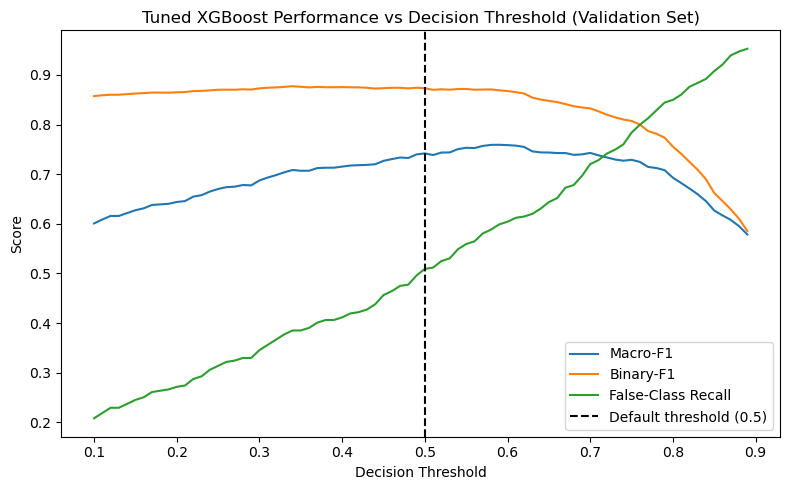

Best threshold by validation Macro-F1: 0.59
Validation Macro-F1 at best threshold: 0.7592
Validation False-Recall at best threshold: 0.5989
Test (threshold=0.59) Accuracy      : 0.8003
Test (threshold=0.59) Binary-F1     : 0.8675
Test (threshold=0.59) Macro-F1      : 0.7313
Test (threshold=0.59) False Recall  : 0.5455
Test (threshold=0.59) True Recall   : 0.8942
Test (threshold=0.59) AUC-ROC       : 0.8302


,Setting,Threshold,Accuracy,Binary-F1,Macro-F1,False-Recall
0,XGBoost default (t=0.50),0.50,0.8114,0.8797,0.7214,0.4516
1,XGBoost tuned threshold (t=0.59),0.59,0.8003,0.8675,0.7313,0.5455


In [20]:
# Step 17: Threshold tuning on the tuned XGBoost model using validation probabilities

thresholds = np.arange(0.10, 0.90, 0.01)
results_thresh = []

for t in thresholds:
    preds = (prob_valid_xgb >= t).astype(int)
    macro_f1 = f1_score(y_valid, preds, average="macro", zero_division=0)
    binary_f1 = f1_score(y_valid, preds, average="binary", zero_division=0)
    _, recall, _, _ = precision_recall_fscore_support(
        y_valid, preds, average=None, zero_division=0
    )
    false_recall = recall[0] if len(recall) > 1 else 0.0
    results_thresh.append({
        "threshold": round(t, 2),
        "macro_f1": macro_f1,
        "binary_f1": binary_f1,
        "false_recall": false_recall,
    })

thresh_df = pd.DataFrame(results_thresh)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_df["threshold"], thresh_df["macro_f1"], label="Macro-F1")
ax.plot(thresh_df["threshold"], thresh_df["binary_f1"], label="Binary-F1")
ax.plot(thresh_df["threshold"], thresh_df["false_recall"], label="False-Class Recall")
ax.axvline(x=0.5, color="k", linestyle="--", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Tuned XGBoost Performance vs Decision Threshold (Validation Set)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "threshold_tuning_tuned_xgb.png"), dpi=150)
plt.show()

best_row = thresh_df.loc[thresh_df["macro_f1"].idxmax()]
best_threshold = float(best_row["threshold"])

print(f"Best threshold by validation Macro-F1: {best_threshold:.2f}")
print(f"Validation Macro-F1 at best threshold: {best_row['macro_f1']:.4f}")
print(f"Validation False-Recall at best threshold: {best_row['false_recall']:.4f}")

test_pred_xgb_tuned = (prob_xgb >= best_threshold).astype(int)
tuned_test_metrics = evaluate_predictions(
    y_test,
    test_pred_xgb_tuned,
    prob_xgb,
    f"Test (threshold={best_threshold:.2f})",
)

comparison_thresh = pd.DataFrame([
    {
        "Setting": "XGBoost default (t=0.50)",
        "Threshold": 0.50,
        "Accuracy": round(xgb_test_metrics["accuracy"], 4),
        "Binary-F1": round(xgb_test_metrics["binary_f1"], 4),
        "Macro-F1": round(xgb_test_metrics["macro_f1"], 4),
        "False-Recall": round(xgb_test_metrics["false_recall"], 4),
    },
    {
        "Setting": f"XGBoost tuned threshold (t={best_threshold:.2f})",
        "Threshold": best_threshold,
        "Accuracy": round(tuned_test_metrics["accuracy"], 4),
        "Binary-F1": round(tuned_test_metrics["binary_f1"], 4),
        "Macro-F1": round(tuned_test_metrics["macro_f1"], 4),
        "False-Recall": round(tuned_test_metrics["false_recall"], 4),
    },
])

display(comparison_thresh)

## Ablation study on the tuned XGBoost pipeline

In [21]:

# Step 18: Ablation study with clean feature groups

def run_xgb_ablation(train_data, valid_data, test_data, y_train, y_valid, y_test, exclude_transformers=None, label="Full Model"):
    exclude_transformers = exclude_transformers or []
    transformers = []

    if "text" not in exclude_transformers:
        transformers.append((
            "text",
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000, sublinear_tf=True),
            "statement_clean",
        ))

    if "cat" not in exclude_transformers:
        transformers.append((
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ))

    if "metadata_num" not in exclude_transformers:
        transformers.append((
            "num_metadata",
            StandardScaler(with_mean=False),
            METADATA_NUMERIC_COLS,
        ))

    if "history_num" not in exclude_transformers:
        transformers.append((
            "num_history",
            StandardScaler(with_mean=False),
            SPEAKER_HISTORY_NUMERIC_COLS,
        ))

    if "lsh" not in exclude_transformers:
        transformers.append((
            "num_lsh",
            StandardScaler(with_mean=False),
            LSH_FEATURE_COLS,
        ))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    X_train_sp = preprocessor.fit_transform(train_data)
    X_valid_sp = preprocessor.transform(valid_data)
    X_test_sp = preprocessor.transform(test_data)

    n_components = min(300, X_train_sp.shape[1] - 1)
    svd_ = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    X_train_d = svd_.fit_transform(X_train_sp)
    X_valid_d = svd_.transform(X_valid_sp)
    X_test_d = svd_.transform(X_test_sp)

    xgb_ = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    xgb_.fit(X_train_d, y_train)

    test_prob = xgb_.predict_proba(X_test_d)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = evaluate_predictions(y_test, test_pred, test_prob, split_name=label)
    return {
        "Model": label,
        "Accuracy": round(metrics["accuracy"], 4),
        "Binary-F1": round(metrics["binary_f1"], 4),
        "Macro-F1": round(metrics["macro_f1"], 4),
        "False-Class Recall": round(metrics["false_recall"], 4),
        "AUC-ROC": round(metrics["auc_roc"], 4),
    }


ablation_configs = [
    (None, "Full Model (all retained features)"),
    (["text"], "No Text"),
    (["cat"], "No Metadata Categories"),
    (["metadata_num"], "No Metadata Numeric Features"),
    (["history_num"], "No Speaker-History Features"),
    (["lsh"], "No LSH Features"),
]

ablation_results = []
for exclude, label in ablation_configs:
    result = run_xgb_ablation(
        train_plus,
        valid_plus,
        test_plus,
        y_train,
        y_valid,
        y_test,
        exclude_transformers=exclude,
        label=label,
    )
    ablation_results.append(result)

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

Full Model (all retained features) Accuracy      : 0.8051
Full Model (all retained features) Binary-F1     : 0.8743
Full Model (all retained features) Macro-F1      : 0.7201
Full Model (all retained features) False Recall  : 0.4721
Full Model (all retained features) True Recall   : 0.9276
Full Model (all retained features) AUC-ROC       : 0.8275
No Text Accuracy      : 0.7861
No Text Binary-F1     : 0.8617
No Text Macro-F1      : 0.6952
No Text False Recall  : 0.4457
No Text True Recall   : 0.9114
No Text AUC-ROC       : 0.8179
No Metadata Categories Accuracy      : 0.8058
No Metadata Categories Binary-F1     : 0.8741
No Metadata Categories Macro-F1      : 0.7250
No Metadata Categories False Recall  : 0.4897
No Metadata Categories True Recall   : 0.9222
No Metadata Categories AUC-ROC       : 0.8565
No Metadata Numeric Features Accuracy      : 0.8019
No Metadata Numeric Features Binary-F1     : 0.8724
No Metadata Numeric Features Macro-F1      : 0.7149
No Metadata Numeric Features False

,Model,Accuracy,Binary-F1,Macro-F1,False-Class Recall,AUC-ROC
0,Full Model (all retained features),0.8051,0.8743,0.7201,0.4721,0.8275
1,No Text,0.7861,0.8617,0.6952,0.4457,0.8179
2,No Metadata Categories,0.8058,0.8741,0.7250,0.4897,0.8565
3,No Metadata Numeric Features,0.8019,0.8724,0.7149,0.4633,0.8276
4,No Speaker-History Features,0.7356,0.8389,0.5513,0.1760,0.6971
5,No LSH Features,0.7987,0.8702,0.7110,0.4604,0.8200


### How to interpret the comparison table

The comparison table is meant to answer two questions:

1. **Do the added feature groups improve over the text-only baseline?**
2. **Which final modelling choice gives the best trade-off across metrics?**

Besides accuracy, the notebook also reports:

- **Binary F1**, which emphasizes performance on the positive class under the binary setup
- **Macro F1**, which gives a more balanced view across both classes
- **False-class recall**, which is especially useful because fact-checking tasks often suffer when models over-predict the more common or easier class
- **AUC-ROC**, which summarizes ranking quality across thresholds

This matters because a model can look strong on accuracy while still performing poorly on the harder **false** class.

# 9. Consolidated Comparison Table

In [22]:

# Step 19: Consolidated results table

results_df = pd.DataFrame([
    make_results_row("Baseline: TF-IDF + Naive Bayes", baseline_valid_metrics, baseline_test_metrics),
    make_results_row("Improved Linear: text + metadata", metadata_valid_metrics, metadata_test_metrics),
    make_results_row("Improved Linear: text + metadata + history", history_valid_metrics, history_test_metrics),
    make_results_row("Final Linear: text + metadata + history + LSH", final_linear_valid_metrics, final_linear_test_metrics),
    make_results_row("Final XGBoost: text + metadata + history + LSH", xgb_valid_metrics, xgb_test_metrics),
])

results_df = results_df.sort_values(by=["test_macro_f1", "test_auc_roc"], ascending=False).reset_index(drop=True)
display(results_df.round(4))

,model,valid_accuracy,valid_binary_f1,valid_macro_f1,test_accuracy,test_binary_f1,test_macro_f1,test_false_recall,test_auc_roc
0,Final XGBoost: text + metadata + history + LSH,0.8084,0.8729,0.7418,0.8114,0.8797,0.7214,0.4516,0.8302
1,Improved Linear: text + metadata + history,0.7788,0.8463,0.7259,0.7782,0.8511,0.7084,0.5367,0.8010
2,Improved Linear: text + metadata,0.6783,0.7946,0.5266,0.6898,0.8057,0.5183,0.1730,0.5737
3,Baseline: TF-IDF + Naive Bayes,0.7126,0.8281,0.4758,0.7301,0.8417,0.4636,0.0469,0.6591
4,Final Linear: text + metadata + history + LSH,0.4805,0.4225,0.4752,0.4380,0.3862,0.4340,0.9707,0.7925


# 10. Comparative Visualizations

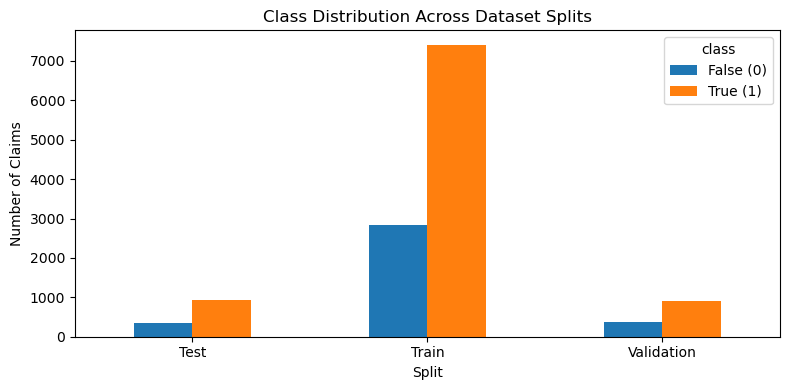

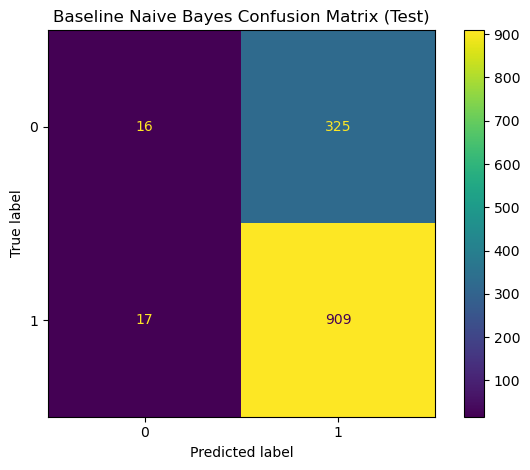

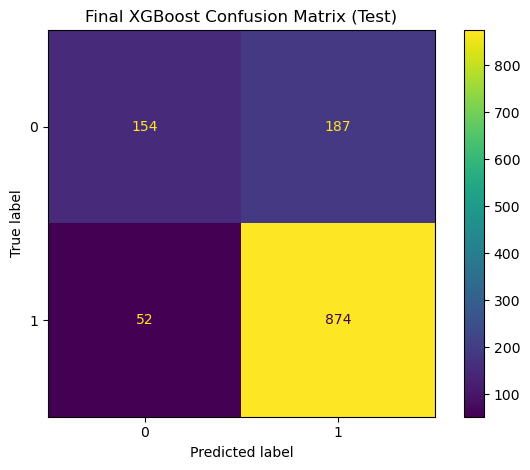

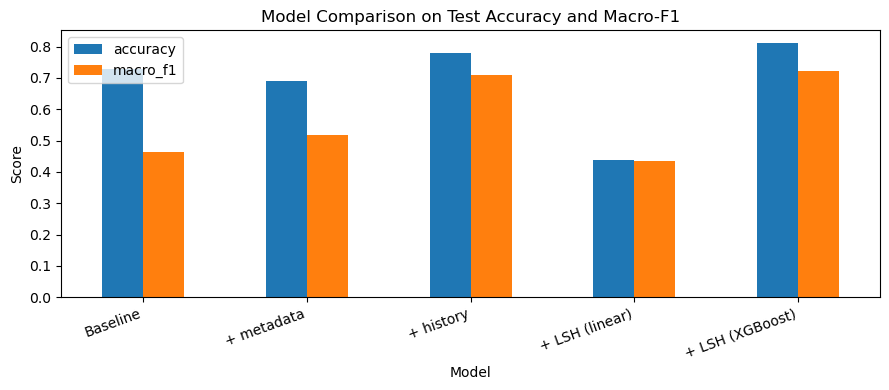

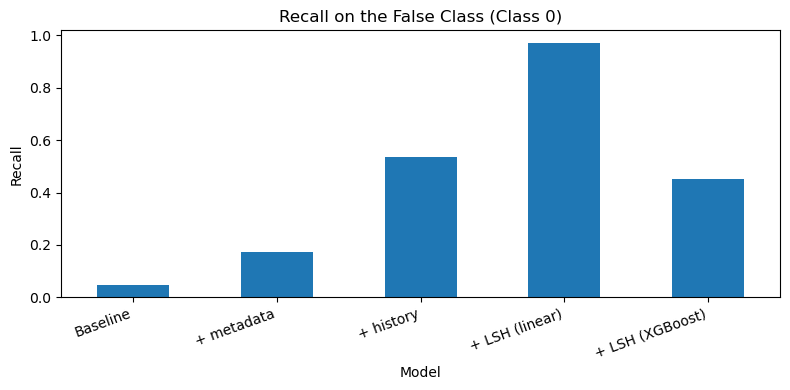

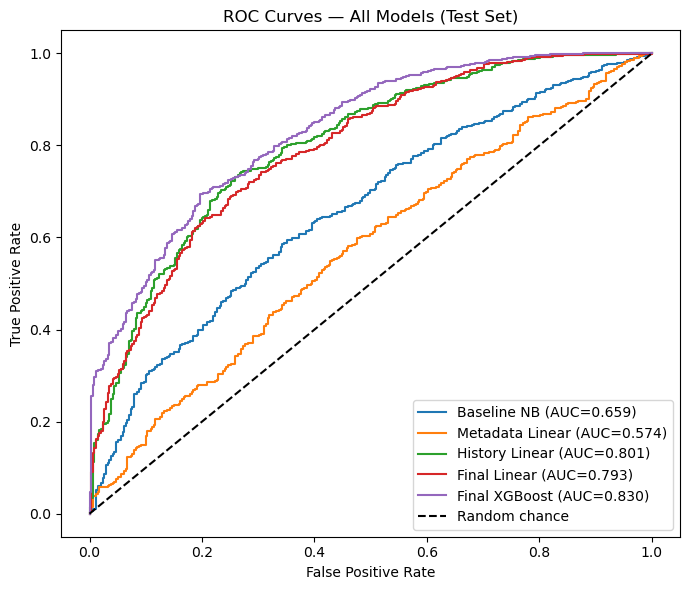

,model,accuracy,macro_f1,false_recall
0,Baseline,0.7301,0.4636,0.0469
1,+ metadata,0.6898,0.5183,0.1730
2,+ history,0.7782,0.7084,0.5367
3,+ LSH (linear),0.4380,0.4340,0.9707
4,+ LSH (XGBoost),0.8114,0.7214,0.4516


In [23]:

# Step 20: Comparative visualizations

class_balance_df = pd.DataFrame({
    "split": ["Train", "Train", "Validation", "Validation", "Test", "Test"],
    "class": ["False (0)", "True (1)", "False (0)", "True (1)", "False (0)", "True (1)"],
    "count": [
        int((y_train == 0).sum()), int((y_train == 1).sum()),
        int((y_valid == 0).sum()), int((y_valid == 1).sum()),
        int((y_test == 0).sum()), int((y_test == 1).sum()),
    ],
})

pivot_balance = class_balance_df.pivot(index="split", columns="class", values="count")
pivot_balance.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Split")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline Naive Bayes Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_xgb)
plt.title("Final XGBoost Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

plot_metrics_df = pd.DataFrame([
    {"model": "Baseline", "accuracy": baseline_test_metrics["accuracy"], "macro_f1": baseline_test_metrics["macro_f1"], "false_recall": baseline_test_metrics["false_recall"]},
    {"model": "+ metadata", "accuracy": metadata_test_metrics["accuracy"], "macro_f1": metadata_test_metrics["macro_f1"], "false_recall": metadata_test_metrics["false_recall"]},
    {"model": "+ history", "accuracy": history_test_metrics["accuracy"], "macro_f1": history_test_metrics["macro_f1"], "false_recall": history_test_metrics["false_recall"]},
    {"model": "+ LSH (linear)", "accuracy": final_linear_test_metrics["accuracy"], "macro_f1": final_linear_test_metrics["macro_f1"], "false_recall": final_linear_test_metrics["false_recall"]},
    {"model": "+ LSH (XGBoost)", "accuracy": xgb_test_metrics["accuracy"], "macro_f1": xgb_test_metrics["macro_f1"], "false_recall": xgb_test_metrics["false_recall"]},
])

plot_metrics_df.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(9, 4))
plt.title("Model Comparison on Test Accuracy and Macro-F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plot_metrics_df.set_index("model")[["false_recall"]].plot(kind="bar", figsize=(8, 4), legend=False)
plt.title("Recall on the False Class (Class 0)")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for prob, label in [
    (prob_nb, f"Baseline NB (AUC={roc_auc_score(y_test, prob_nb):.3f})"),
    (prob_metadata, f"Metadata Linear (AUC={roc_auc_score(y_test, prob_metadata):.3f})"),
    (prob_history, f"History Linear (AUC={roc_auc_score(y_test, prob_history):.3f})"),
    (prob_final_linear, f"Final Linear (AUC={roc_auc_score(y_test, prob_final_linear):.3f})"),
    (prob_xgb, f"Final XGBoost (AUC={roc_auc_score(y_test, prob_xgb):.3f})"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "roc_curves_no_graph.png"), dpi=150)
plt.show()

display(plot_metrics_df.round(4))

# 11. Error Analysis

In [24]:

# Step 21: Error analysis utilities

error_analysis_df = test_plus[[
    "statement",
    "statement_clean",
    "speaker",
    "subject",
    "party_affiliation",
    "context",
    "label",
    "y",
]].copy()

error_analysis_df["baseline_pred"] = test_pred_nb
error_analysis_df["final_linear_pred"] = test_pred_final_linear
error_analysis_df["xgb_pred"] = test_pred_xgb

improved_cases = error_analysis_df[
    (error_analysis_df["baseline_pred"] != error_analysis_df["y"]) &
    (error_analysis_df["xgb_pred"] == error_analysis_df["y"])
].copy()

still_wrong_cases = error_analysis_df[
    error_analysis_df["xgb_pred"] != error_analysis_df["y"]
].copy()

print("Examples improved over baseline:", len(improved_cases))
print("Examples still wrong for final XGBoost model:", len(still_wrong_cases))

display(improved_cases.head(10))
display(still_wrong_cases.head(10))

Examples improved over baseline: 159
Examples still wrong for final XGBoost model: 239


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
2,Says John McCain has done nothing to help the ...,says john mccain has done nothing to help the ...,donald-trump,OTHER,republican,OTHER,false,0,1,0,0
12,Denali is the Kenyan word for black power.,denali is the kenyan word for black power,viral-image,environment,none,OTHER,pants-fire,0,1,0,0
16,Unfortunately we have documented instances whe...,unfortunately we have documented instances whe...,OTHER,"labor,state-budget",republican,OTHER,pants-fire,0,1,0,0
42,Says he won the second debate with Hillary Cli...,says he won the second debate with hillary cli...,donald-trump,OTHER,republican,a tweet,pants-fire,0,1,0,0
54,When undocumented children are picked up at th...,when undocumented children are picked up at th...,OTHER,OTHER,republican,OTHER,false,0,1,0,0
58,ACORN will be a paid partner with the Census B...,acorn will be a paid partner with the census b...,michele-bachmann,census,republican,OTHER,pants-fire,0,1,0,0
59,Sixty percent of the Hispanics support the Ari...,sixty percent of the hispanics support the ari...,OTHER,immigration,republican,a CNN interview,pants-fire,0,1,0,0
76,What the facts say is ...the best scenario for...,what the facts say is the best scenario for ki...,reince-priebus,OTHER,republican,"comments on ""Meet the Press""",false,0,1,0,0
80,Rebuilding three high schools will benefit 40 ...,rebuilding three high schools will benefit 40 ...,OTHER,education,none,OTHER,pants-fire,0,1,0,0
95,Says people in Africa literally walk two and t...,says people in africa literally walk two and t...,OTHER,elections,republican,OTHER,pants-fire,0,1,0,0


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
1,Wisconsin is on pace to double the number of l...,wisconsin is on pace to double the number of l...,OTHER,jobs,democrat,a news conference,false,0,1,0,1
13,Says 57 percent of federal spending goes to th...,says 57 percent of federal spending goes to th...,facebook-posts,OTHER,none,a meme on social media,false,0,1,0,1
19,Ronald Reagan faced an even worse recession th...,ronald reagan faced an even worse recession th...,sarah-palin,"economy,history",republican,OTHER,false,0,1,0,1
22,The number of illegal immigrants could be 3 mi...,the number of illegal immigrants could be 3 mi...,donald-trump,immigration,republican,OTHER,pants-fire,0,1,0,1
24,Says Charlie Crist is embroiled in a fraud cas...,says charlie crist is embroiled in a fraud cas...,republican-party-florida,"jobs,state-budget",republican,a TV ad,false,0,0,0,1
30,Its been since 1888 that a Senate of a differe...,its been since 1888 that a senate of a differe...,cory-gardner,OTHER,republican,OTHER,false,0,1,0,1
31,"Under Rosemary Lehmberg, the Travis County D.A...",under rosemary lehmberg the travis county d a ...,sarah-palin,"crime,criminal-justice",republican,a commentary,false,0,1,0,1
44,"In 1993, Newt Gingrich first advocated for the...",in 1993 newt gingrich first advocated for the ...,michele-bachmann,health-care,republican,OTHER,mostly-true,1,1,0,0
48,A proposed tax to fund transportation projects...,a proposed tax to fund transportation projects...,OTHER,transportation,republican,OTHER,false,0,1,0,1
51,Hillary Clinton said gun confiscation would be...,hillary clinton said gun confiscation would be...,national-rifle-association,guns,none,OTHER,barely-true,1,1,0,0


# 12. Exported Outputs

In [25]:

# Step 22: Save results to CSV 

results_df.to_csv(os.path.join(table_dir, "model_comparison.csv"), index=False)
ablation_df.to_csv(os.path.join(table_dir, "ablation_results.csv"), index=False)
improved_cases.to_csv(os.path.join(table_dir, "improved_cases.csv"), index=False)
still_wrong_cases.to_csv(os.path.join(table_dir, "still_wrong_cases.csv"), index=False)

print("Saved outputs to:", output_dir)
print("Tables saved to:", table_dir)

Saved outputs to: outputs/liar_project_outputs
Tables saved to: outputs/liar_project_outputs\tables


# 13. Conclusions, limitations, and next steps

## Main takeaways

From the consolidated results and ablation study, several conclusions emerge:

- The project goes meaningfully beyond a text-only baseline.
- **Speaker-history features** appear especially important; removing them causes one of the largest drops in performance.
- **LSH-based similar-claim retrieval features** also provide useful gains, especially when combined with the other engineered features.
- The final **XGBoost** model achieves the strongest overall performance in the current notebook, while threshold tuning slightly improves the balance between classes.

In addition, the v3 notebook shows that these conclusions are not tied to a single arbitrary tree configuration: the final XGBoost model is selected through a compact validation-based hyperparameter search, and the threshold analysis then examines whether any remaining trade-off can be improved at decision time.